# Análisis del rendimiento de estudiantes

Este notebook reúne en un solo documento todo el trabajo del proyecto: la carga y revisión del dataset, la limpieza aplicada, la clasificación de rendimiento, los seis análisis, las cuatro gráficas y las conclusiones.

**Dataset:** `dataset_limpio.csv` · 1000 estudiantes · 8 variables originales (género, grupo étnico, escolaridad de los padres, tipo de comida, curso de preparación y puntajes de matemáticas, lectura y escritura) + 2 variables derivadas (`average_score` y `performance_level`).

**Contenido**

1. Carga de datos
2. Exploración inicial
3. Limpieza aplicada
4. Clasificación de rendimiento
5. Análisis
   1. Promedio por área
   2. Curso de preparación vs. promedio
   3. Promedio según escolaridad de los padres
   4. Promedio por grupo (etnia, género, tipo de comida)
   5. Porcentaje de estudiantes por umbral de promedio
   6. Correlación entre áreas
6. Conclusiones
7. Apéndice: salida original del análisis (`resumen_analisis.txt`)

In [1]:
import base64
import gzip
import io
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", "{:.2f}".format)

In [2]:
# Copia comprimida de dataset_limpio.csv (respaldo para que este notebook funcione por sí solo).
DATASET_EMBEBIDO = """
H4sIAJ6XsGoC/61dy5Ikt27d+yu08ybjmky+l/be3zBRXVUajWM0regZXYf/3gmAzM6sIkiQdSP6dkgOd6kySYLAwTkHX+8/bveP
5eNyvX+5//rjx7frt1//t/x1+bj/+HX5/uX7/Z/371/ef/9yv/19vfz69v5j+f73j+sfy6/7z19f/vq4b/+f+H/+cn3/++Pnffnz
8uuPLz+v7x/35eN+uX378TX/2/9+fPv1+W+Xf94/Ll/v+d/+un/8/v7x5+XH9iXwv/hvv9//vHy/L18/3v/+67e35e1y/eP+/f3j
33/+drt//bjfl5+/Lj9ul4/b8uP9x30JK/7Y7fc/fFj++3779n7+jOvy8/3P+2/X9+/f718Pf359//Ov7/df99vi05LUEuMS138Y
s/zn91/vj1/jz8vPX3f2S2x/ndySzJLwS+AHHP78slx+/ny/frv8un9+wu/br//4gJd7z59iw+LCYu1iE3yN/7r8z+lTuOeg1+CX
EJfgtn+Av628hrfal3j4EL1Eg58T2A/pvcvtLcKrWJeka6/i4QMqL0Et1iwmbf8Af//4Em7LH9++/vHbz+sf7+/fz39+WE+LP2Hx
7h+q/hjsp+CXMHHxanGKXYnuq3RxcXZx6/a7/hjdT9hexPbn27uw8BD4AY1nOP+td0vUS9jW0uwv4LQfe6sIe2A7VQo+oL4TLp0j
sb08Z/A1mP0F1I5l4yES7uftm9jaQ1wbzw9HOS3RLzHsm7C2j9u7QMfFrMsal9WXFTj99x9fALMbrV/sir8t9yZE4QH207Yv9RYk
+ifj4VV6eJvebP/AHQj+WB7OlcMV2XaFqq3IrRWgtrAGD7BtCbUfqfH9YPBHf0b603/++a5gHgSuiy3WbQ/i6uejubQUKw1dOswR
e2u9i+1J4F24xSXuXfSuPQhudD7U5wEVng5cQFhMH5nDfescbk+xYfuEVN9Pt87jw6vDK3vsmqE/N/jd9fYP9f/4XbB8zsPawefY
6vtr72UFJ3q7JKyqBIZ7609T2GLSlmdsIap2Pd6b98LhltUY4LcYp+oZi+CC2RYg0oWf2G0giJJboN8uW5eOYan/VbiD6UomZvfn
6uUwla8UYH3xdy1SSuMtbjI4qH4gbj+lAVug8BEC73RaRvfotlddrD2OLHZvCwS73cOpqX+Tu/C1KHy5EMtruZHgeeBJLC5PrL/Y
i/AUwAo5CEZesbl/81LcLgFInDUXxOQbd3saCGj+GBH73+NwoLeIYPH3Wo8LjZgC+8Mtdku11mo4Gjh+eKts23V7JfVbpf01oHaB
VKe2MW7tfI2qFy6cXTuR6PAIGl9kgI+qpn7XXu6/PYamGqSad4tD9LaWDnPQaigTBGioHrZ1TfV1vXWTeEi+E/6O4pTr+X2oRYdF
bwVudW/JU65U8iXXKEk6S5Pwxy4m1HaYsMyGeKHb2Vc/hCXMHjVfH9166WxemtSO6o3wFbDI1ZDB8Ml4+4Vat71K/EnNIo1JxFSG
XnysJuTC2xoWI+KdEqfXY9sWnq4UU/+Mm+ySjJBdwo1tmRKjCyVhLIYUVbGFswwM2t6KhqBumRxGsLxYK+Y3qyQf8ZDmJvzRTEAX
Li/cCRqTZc0ny/yXMGorv5d1rRfhl1ahdIjFCu4XzJiZRKF1XA+rq3MQ4+qee79wgmQwNgrxPjAU8E7YahAmcHTOfIJjDz++HkRF
B0UhWmmP1bz4jiy4LYQvc8qMZUAfPcZa7oL25cbApQb2xHZFB64EvvaAyi3X22qnBmh8EwGuIW+p+na4NBOuiHU8D3N27yB4DR4z
FTbv6gIRruDvEiDi+TWuARfRL2atQ62Nb48VMF3CtWh9Hch8EWfFbe0ZtLW1mxBrTJDw1ZL3ke9BYeq8IsKs4ITTQaG3nsCNhzgl
uMgIAW6ARJ0TArdpwK+xsh8h2F75MyyTY7TXBf44HCs86X/98CbiJ1wlrxMfChy3JI2YdKwva29FFd6jgYm3/RZXirhFFbRlWhUW
G2ngLQJgxt6f7YsvQg2h8H/JvYJ8IYJBHZ4RRKWyO1es/VUPE2/iqJ6ygci+laHae9sfsE6QrD3HkEYlsNeJTlwWPawvIvOwvbQo
fX74a13aXbb+13fZQUvpc4+keiBtQAgW3iCc0sjui06xSovqsGxfWfygH7Mghq94Nc1km+WVwi7XvdKdWRCHMI5jEfKrbEG2R4BL
DW63ei9XdmQp8kFLmIVkJF1lgz+6DqZ0CiHzWQhVUuYmuhYxVYR2D3fKW53YLe4lQoHS6H2+p8l0jaaRltu5Zxcebq+RuL3iXrZ8
k+DSPQ9QxyaMEqoODHa+QirQqKsGRikyuEU4E4hfUK9ZJIVPpHepgCKh5tgmAZvz8Eiq8jyDXcyUOR9VzLm7MLEAx2YUgjq8VuyR
AErAnK3mBQownOfBEkmLJWFOENo4WGs9NKJokCvOllHYTKRCRE0Vk/AQVBBrJsjItqfFVICtyy+NxQDqkSFwYQBt3uF74g0lGQer
UgZSOb8dUV3HmjpLgC1DPFprLc4KW36lV9foa4tLBqLg1KuWkZ7MnhJtl1+os8tENeGaOQPe1/H3blaDlRQ8mWLvQWHbLlHafcQt
hhIsiDcpV0PsVm3my/Akmm+FCoK4omqORX/uIqKap4z1RF4cYcttdWH5mcETT8gm0qUgy6muiQzK9yWM2TopRr7tEZvL+byaD4hw
DCNl9PUUtk8VgdzFYDNOjyJU8EeGkh+uMurkPpqolIeicCaRT/4zjMR+ZcUnUE7TT71b9CalxAFySYRVNZZTn0Js5qr6CQT38Dnh
k9NWO4KX3hdBChhu1CoRrNvgSDa3vw9Flrz2JugRIUNmg/R7mQZfAgIh3O0tzkmtKQkh21xld/yJ3gR7PsA7YQjZgv1qfeZMunWG
wHPKEKGGCsfe9eTGJ0gVOtATfePDgQ5HqKRWFQm/EDWkQoML2E3dttcMEd+zdJ5WCeBU7iXZOtviJqIT+ZSRasVyViT7xSHjOjGV
zAiMn2FrdwJMha8E0AaPdbtpNaEF+Z7HbNZV+zIiBjRyirBXGGeJqgBrRjzKthqgBK1CzBRz6jrXladeHSFyTcZpO2nEXT5dZuZW
CFtmiiKjJzDEnZ5k8LwQ+WUFXqMaJhacGYWpQaG9d0A5Kv3xtpC03KrsFaK+Oc18gAjwjbgxPCA63PUnzKEDro2HtVFTHbOs2wCM
iWmmSphJxOILeqpMK1gA8QCZrlsbfSbOyBY3Qh3uk4QvYuiT+KO+uXqBJ67lvMWREHzmWGMo5pazu0GJYU1ba+4TSPABUUdL7wKu
nlIU/7jA0b3mjUMpTFiMqp62a5+wgUxdRhE1dLsqDBseGl5yyPEE4iYk0B/Sy2HcE466yZzVat4+AvJEImLEI4NgjLVqCyMm1vGz
ToPEY9RRTKf8TcqOgjXxDSVAD0v2udteB6kEkQsSDYe8Ft3sNXWvpmdi+QjEBIupWoRmMVaGaRzgkoYFhgUQhiucfT3B88wSW80L
r5qoMqT4lmkxiGi/Pha2WJztuWRVqgWBbrV/2JbW5swvymlGD5Q9j9g6yDk55EQg+IqUxXLXWQ9nWAneY0lKMialKVIFU21e9Q8o
Hgssp5kEVpK0IW8wU99eqaNhYVUr4LTyHNL3aoAX5kTC2APEn9Gu9iFR6rUsBJmSwmU1HIbUPN8+yxQO3A+xbgWbwogYzcD4sI0s
Zrrr7LmEq4JUQIHJMvsfQbWD5XtfXSgz8zgjv5k7Wm/YxevphpAyh0jnfmarD7eWiJBMuMkw+f5gPEBSxGEu1ikvzNpWDijooO14
GOGuCwJOcjUarCzY2DwKnkBk1YLhZB0YWyJCnKggzwYA4TFMDzBi1ad2n3seKULpitrVtZvLMmOIgPXxUbYz1vejGirybCBRgglq
eEUCD64x1LjJEzaD1ZbPVO/gNlHBUD7VUj13kuOEmYw+1vejpHFT+uOGQ0raPgArLuI6QrtkssIVE0PNlXD9wEUkUuaFCl5Fykw/
bycklxHDLoDWs9rr3XnGtDolbT0/9c80rwMTpOd0FVezyv5LzJ1AwzaLr7KSnoxr4GwxWHXvJk95a3v3SnTwrhSQoZ6VinBNk0Xw
niH+Ne4ybHfTtlJDQl5sFWC547lUQPjdAwLdIbYZtL3uv6JQDXfHJO4PlEFPBVzlXbwN+DUgkzLqV8jvKVtHAJtUyWxtnqvIROxk
piskWZ6YnaZOOa+wFj01RALBTn42f88EflavLsFpKO8KvhV9e3mnwTQ6sCycu0hGhZGDk6pISkHM2VDryCyuLIUMGaj1RqjUrtUE
PqvoObKtvPNu8wKrIXHZ4asoZAIoMNKq9iNEbwVsSZAqEmtJl0w1GXXRd9WZv5Lky3/6iqkXKA25V8VWvm8yJMdTwTHF3j03exxe
4qFVhrJuQpnYGJkavquNSggb60NUHZFJIwKUbfvqbUiZHslgChV4pPfWV/YC3MqXoBILQINpGBsQBUClL8HwJdEdETQbmMhQwyh+
7pFXBDEObQYgv/OjlnRBFx5DGDfdOqvEiBBoxDzn51x5zSaP9WxdUr0Vwvys7q0EM09mCZpdZElVH0q26NkeSRNGxJb9ISgPtEZ0
aROHNn2qc3IN5tyGreO6zVVdegxmQi8GO0oREbHeGmiFX1JPnBltwpuRmP9xWc2i0/Z7HEY/84WprxAn5ZyWeDG6XvX0zrbirViu
Ik8HcGFxRyOWGXHsigkCqN2Gi5WS5eQMxYzzjUt4gQIafNy4zmePBKNLR8MJjW3qjC+oDBLXs5SsSWlP2MBdp4KjvYJDBdAm1tSE
VgRxbtse0JhWddlDL0Rk79D1sDfkVmmaWtA8rtHna+99EiMWGNTzgkDyjTjEBSxk6UBkZ1an1VRi5t6lG3ciyJ5TfIUoVeQGbGI7
JlL3MsTcMvPcqbiLCBZkdMe3arrynbXwOdcGY555kb7kuIPC6LOzRSRN7xThr3T0AS4NPXtjtvMJlW2Dci/IwnQx6AiMcEHE/Kfr
W0/o9k6qQ3IYdgLpICt+1LyNY1t9qLA4T0KxwLOzxYqd6DQvgQV5kSXZ/4y5xkoefQc+7rgLa7bRWUE/qcas4+H1K/KiEzpscdsA
He3gs1yd4de/ItAv/BgkR1Qoe/bgKSVlNtNF2KDzpB1xzZ5221sJmdoHfqDYc4DMLHS3rOgdTFfayuscj60Y33R9DlvNnRVw6+TZ
LptA8JnIi/5UPI9b1+YSSbNVUh8vplizcmqGm7SrDa0ml3W99Zhx6a4NmTcHpkt0ESE1NnsrzZrRAWWCjNDqnTth8RayM1C9pX2V
+LEnRDM1y7W+ixxGY/HHq8OrF+mHGNppXHO/leFQW8Tx7W1BN8GWc5+4dFNqpB0IOuNBq65kxp501gN0nNyZcRzB6y43BcasH50i
BsPYLn2PWZYxmrAGXzzI1Dg2cPKXRify49060eH2WAAQd0L1xK5VPRicDc2OsujxzB35FZpGHSQh7YGdEPxuTJhp3mnkB9Q2eW3s
a4UJo2V57rK1oM/wgUl3Lj2vbfph+uxd2M2idAs1WNxd2Mt6Y3HsSiLRwjNfDvP+AXPqZxi6UN2GxQJnqSaB0Hbeoj8SOBBall8S
Sd1afKpctZAS36Y583ScM6mk06CKN6luRd9W4mczMadOepD5o1I7yTcxF0F7PmSy+MsCd0dld+JT0bZHnaG5LeNssYGmuGT0RwbC
9Pj0Ex9Lxc4YHkg2eiidbDc7E+lcYCDqfPBYG9QdBaxc7REFmMvrbchmmS40A3P/bsDKkTMQ6mtj9ac9surDU3WX/NCklXc7Ab7I
2mZ823aqp36cVDQsH3J41Zo6vnEVKpAgZbCcDFNOzgb8MjV8GdsYfAvv6/wtXioju7LOEkXj8eo8iqsAEIFg7nlqutR5PD7MERu8
VBwpm1lLRZlVmMvCPHZUStv3jpTvaVD4cgh62X2KRT0FQHjIQ6SCEyUtzy6n1PpOrwBtLuU70YdpECKQdsR3+EOd3gjxIl/lEPvw
WWEJGlTVmLfnPFOThHxel7oTXgsMt6EMK3Rz7eM8dHLl+bZCU6acvkrNv87fAkuSDDpyZ0MWr9veqVeBnQMx9F0YmGxSpYYRx8Ix
xjQSYNxgyoVLzOU4XS+XhGEnMRLSm/hpwB8qsmLkPr5VvI/y/yrpxZvAtsu7plBK8lKzasIx1tt9fwecimlZC5N7h3wUyKBinR5i
EcgTHm6RGqtVVo+43Ebj5lBcO72O7McQBuZoVDpgfjE4Z8boutJcghOuxbYpcvM4JJ8Siucgw9FrzYfUub3OT+QQggAGewzqsLLy
VNPkGZ0+vmqJE2kC2tCMyef2ZMgNvRl85sDzVXmzJ3Zoprj+Jim+Z5AR2cf43aRrnBFTmi/kjdDoznWmNKN4OCi2lhdJMHQDSugH
YmKTNrwgb+KBDlCeeLb93LutaTCT5sCmpnlyQg64P3oBDM91SsTrP96LAxN9bdOho8+5sxmSeWlGtVe7LP8VwI4GRYf63LLLyFCN
9Km7UtUmqzQRzFYBbt6onHphjYEj194YAhT9cqCuAJDRiNmrOaIMdfLimJzwTMEnF5WZp88J4yodUMJb1oXYGvnaF9D54owWhlDx
Q6w8zwwfCtfk+N8aWya+CynrAikBD8414oUps5ET1+IWfg9XZoOsM4SKMo479+N0y0iwgcuvuYFT92G5tB00spd5nJfqOlceoO7I
2NkUqbg1zIhbClRL9kD18VQ3waY2nKdCl8fi0QsBJBCr0C+wilaX65O7f0Wwuy2FNiflErYBoK5Cqi7XkrhKWexkaHZwLx+gLdh9
dgrnUd+FCDNluzEjW3Sh+6LDZplGQp0PmXXaCe63LjskTE+ZTTpXMzEIJ7c8SRWJNOw5zLgf7Khvjp5qA270ZxP39cGSXkxNipn7
4FepWpq7iImiqbiD1rU79IUCYRnOrCTuruRUGrhR35KkLs++/JeUyqhMgNRZLCV7wm9pkhu3tmIVEc1kZsfyiOXb2KRIzIGRlIZ5
HP2AaoIftZEtpsJLxkhOF7b0GG9mH+vm8/1SlXnJPPio9aQZOtpFbiYBl/6JlzsSSYL7XJ16OB6u09Qk7LU3H0J2uJ2e07nmjPSg
rxnK0MtMY94UW8xZjHn0HPdKZEyCbYmxH3Jqhgwt81pGzfP+2N3kLH+CFV57zwnuioikmbp29g8prvpTzidn+2CFEG+cMXctNQsU
tMd5w0OGeaGwa8OskMvhxGPLTjzuG0LvI7vsa+M1nCuUKs5gtZ8WebJO8CdS56wNA3kI2jlLmUxzWHvj5Fomc+gxgDt2Aivxpsg2
1Csss0TjgrEyl9Qe3L1riq2ifcFxCLuF2Jxm7K37By7mGd/WyYfUMs+UYyrFVSnFkns/uhjdqzqA0J1sCk8Wjp4f4266sThkhEkD
N3gEl33wprQo0JXx5L427sIA/fE1G48PVhMnYlEWxLAmTk1OeVafOAYEGRhFT1MxzXGEkoAXfvZh1xkMEbD0nyeO0aTy0LIY6wnP
Ik3b5WyKun0pU2wA1OwIZXiQIjtroR+NRSVfEdVyoROaVefxmPzQJ2E9lQcOsBfDreOUlD1d7QtdDOqDNEgHzT4ZCRJNYwiO6Dqg
LHtli7BeMwGOuTs6FI1J72z2p2DquKtgrEcR9DSOeNtwZMWIpett2y4SFfeGzIxljs1Oso2NJMsxcnGS4B59Yb6h83uRMHOJGgU2
HdqBBY0aX40uoannZhsyfD43fdjTuHrdCAqdYGvJ7U8Gxp3/dk3wAy8wTWgdaQgkRdgx18NdiBVoFEy1iJJqcREnR4O/hv1R24ie
htukeUMJ8hCAhTScmErWCYt5/POECbkueuB1XgnlIvnEsH1iUdGQ8o7klMk9V+Q8FFwPz0U/dUgzW4idJCO6LB8JpH3+wTMk1VS3
NJlchSHUiPO9uwIccB2KmuvTlrvNxViwrPrIkHZwSmT/bo/jUeeHMu6CwTkky7jS9lZVgrQoG1wx1Hpu5oKsWIklxW+N1WnUCHjt
ekR/ubmMQreNTP1UQ0Kyhy8SMAWIdTnvwALTGFDWJkI2HJEMrOskrJtAVusC+c2+og2G+QBkR6f68OCTf0CmGYV+LvQEtKLugKW/
vgnNO30piI3ooD0bMjZGdvcLP1sG61T//tI28gs2S4MkPmd8oxrJJL0yrafkQPgtRib0tR1kfLFbi1NDEvb0zD7m+VIneJ2nI9ko
H+zLtUJsIa5Zqe15BTJfi9opsF1NwVDKlN0+6zhZk6Lp3YOsZ+psdcehCBaW/HRodKuk/KtLGdfHCaFyMqEqk1sH502cY33KZ+xF
LoIuppmGE0cKZtGTEMMOGpidPcS2yzgeXS0GUsVzlqMeKbhjfLhgypwb2dzSZ9uX8DibbZxKHELpGqa5RkwW0unWjDiZbZQpLX9T
zwkktqqZxxUEipDqINkMEjTn8XabUqZl5NPDrFxxfXYT4mVXfNrDC1oHsiCNL4+BAuAMf5wXmTfyra0sXhiwwqxudNwZnIVWCz/B
Vp/X/BkRjyfJI5X8bI8f8w3PtbEGJBw0MNRIetLPSFrMUfi1eQTe5SQyhDFh9Pl6Cpnx2IzCjSsBtilR5tWYCvbcMIhZuCA+NXUz
GGCd+2NGO768UZepcHEUGzr6lSreL76JtKJ1MBnaDBZGBKN41kfxre2ChuMx+eakNGwBXVFBaWhCw6u0lTNluRl/I94lzkCAjKXS
/R4oTE7JDrkwvLSd8gEzzKf0zMxIu2s5vVV39hvN4ANcK04DhDZl439eCy17FSZj6eFfYHHUL98ltWMoKctM5NktymiIWdMYt5E2
kVgdKNszK3SiOtKMBI5JfxFZmK4PsMxUD9jtLHg9ih/uCqZiQjMBCZ85mzTWTNXfbrfOcKH4uXOsCRkfNmQROSN1vnXYUp5c+Ky8
XOLlZfnjxCyYKj6cvQn8OOji0fLJg+tTvy/97KxOAonRoX9IFsHt4Jj3P0B+Kdzzeq3VN7VJaLuMhuAMri2E3siAJBqO39US8ce9
rZ0mWh6E75BuZ3TK39MwZNsAcwcQOJ8Vg9zweDl/hQTrr6bowOvxTeJAewouIZtu0k368D1Q+naWDg4breWLIQrHnXDRh1SEibUl
lQeyYAvDuW7H3ET2oH+yHl1mpMAReNMUe+5+QsaUsfaRhTclXPGuTBNapTT+Oi7odNaxC4gh1bQOOgB2AhrYckpgZ4fD3NLp0+/3
wZJOOBGyCh9l+/U4VNqfr/lEbXnZ9MQn6hlsMCDqiLgRrNlPmJPpoickpgizrp1pzXPOmHtWRs10JhvX1YdV3WRCG51TezWRgJKC
yjFuVgJCgfp0GZOzKuqOWGR6oYZ5T+WCboz8EKbzKT8MJyDvw7K0szn1dL9SW0lTyyxnj7zmGr4jPbwuO0q8xAUlMBedXwQWXHz5
4FlXMxFAposvRBqaQrqbCKwNm9OrWHZOqKNjGzdX6WTmRAmwlQ51qHNcHbX5ZiwiSis/0Ux2NexLgAEG65mameGA2iPsLktKRLpu
eHuT53qcRO8E9O0u4hXWPJBhjmtqYyEYGqFXQ217kXOoP/qCi1vHfs0MKkaD3i72M82VlxW8dWjPlKyvY7SWE28r55VqAIN+8gzj
PYT6XdFYxDqT8zrziKdwNO6Xtv1XLA7ScczpmAGlyy0v3kdCXC2tBXsys4jpXr4RHGcE9/ezmZDLk9bnsKcdRKZga5lUv+lnlKvP
NOshaRxm1Qb4odXEus9GpBQEOkwzctazqxGx4cMkErUP9/N5uJ/MBuYJ+0ayEsvlFrHIwPzFNbzLxBnmWiZtBKl7bO3V6kyf4p9J
EvsNccK2/bI29QJdLldOdfwEQUUntAldjyNZJ6zuIkmIeOBYZOey5k/hjLSafs2ZesvyGPodVRQ9IhdMADbX2/4WM98kHdHEeJkj
w4VDW5svYf0kGsrzTH4uhY/ElhmthUg1jj9ct17WyqPIoU8eb+JKgmY5WlbaJoAZHDWsw1E+OmWDbhr1kNz/SuUO7wygVybWplxH
SGCTZ2s4IuewLcQOP+epLTuSbAVXQE0vYxZWmZrZT0BLdM312fJkFLEOzkVPKpvEBLE53rOtKjHhbUPm0PTbAU9oDwZPVZ1l58kJ
MkwwAbwOEAnYElltGrjZIcIQiSAFnId1XAVEo6txFhPjwSBykiGQJHCdtX4P3GKHwltOrydnKBTnc55511UOBqIv+1l2QiDT8sga
sl6ks4PJZoN5qzKJeUB6PPQ+a0Zbd5lmP+WLlJOu9F4qDCQNmRCgZJ6HdacPgm3WURdkIh6jHmmku9iwqIvZCGZyixDrFW4AJa7W
eWkTDfYIcdhYeZ/aRd5wcXJiYMbtA5uqDlCMAsWSVG9sXSQDTomSPQrknF36V/wKa2OMJK8wVY2xDf1R1yrfy/U8sym+R4aJaxBW
LgLntkgVFLeZBo4JdcQMR9KSqGR9oYqt3DHpyDKL+7p1oxnr7kCbW7XDke9AzzTIzQQKzugskLPEKDQJu/KYYbPEh+mM3HvKW1VE
6YxxnIQqqguPpu6Y2l4TNAZm91XTjX+/3Sd1oHFPXa3Qk+zZoYMELHHCJiV73/D697b2DwUFyTBuzneBHTZN3OBGFveOE/YYYLSE
Yn0Eun5Qobj3eEF0ro9nI4AmzViU7Or9lKV2M2A9+exCWKoPHpRx5kNpdod5055skMUG6bsAqcotm1MlPJe9b+HargjBJZH8hvEb
09lVbpJMEZDArcFwjO/6ttrGZBov4khVx96RE3O9sn2TKdVXLM5jtb85QO6LpbVlX5luiZ7SuX4YbQxhB8OGxviR7o7Aio58qcQ5
DbOsNg8trgZP0bugUUPUiBBP66grD4kQ6+pm350oGIuCiFNltW4Rnd9FfY7gVULu1ln30hrZ0bvGozoZWY7qELwtZE/9ihtm5nV7
fkr4XT48qsDE3OXYlV7vssN6diOcOQE3kx2DzZ/gNUdLvE7k/iddUkZ6V1aSIGwAmjyQHvKGiaiMYZA4erNwK3I8QkO23ME/LPUy
AHMcsnA6TwB1rYl6d5EdVVofFMsP6auguaVKH8AMS7gPjxN3Q9yBxsrzEDm0kPaGPb4CcAosjy1mLsyt3Z1aAH5pYTHqVYa2N5+0
g1eUvx5tCFFYOTGg70yYxnHEHImwI3lw2YWNnVbYKbdMyWLcC4MbDbr4QUql56ZKPAWiB5HkUCFfWMNZihzH6U4xZsbYQaElzchC
9lxmQrvAxBqbuhCF2M6ZiF8Tsr8ec39Lr11VXJEYlYWQamqJwuTHmC7lZiDKMDu8S+p2iSkh6rW4bFm8T23IqmAOFn4TU2a8bnCQ
uvzXxhAt4RIzQ4HFqJFFJwXqPExMCDorNEkuoVvttpaIjdyw9dF7fYSVQfY+4SWjOzCghgSxztRrNhtJYjqvO9tdSV126Z1JpPJY
nsTI/WVt1+wGplicXkYVssgnWxulkOTKd9ksnplPOlLyZymOhfVtGSj3e3WeqoBRG+QzU8Q+FkRDGTeahrQ8CAeUTkXaMjsV/AxI
OPJPG4eoDqEg5nkj9Sk9fQ08UZ7jiWM65kCalUusP3CPQIJcYfwdGqTxjjeWzmrceYVGIDoSDwRIRRbrzpqdnOIZc4Cv4/Md2REN
KWAOy0VeQOgMLbGJfzM93Gclry+g0rZovUO/mupP7Byr04k0jUK0hhxD0mWjaXzrEfaUHo9zzuAagafVEU4FEOoNWW9l6474l3xy
KiPm2gIlG4E5RV0gkYdgDyLBe+cpkfHb7FiksN8mZlzSlm0oNGdU2TU7lgyWaWSwLstbuAnobdPVMsCEYxW0CBE47MPz84Bv0nzC
DrvhPJC7RVWAOErmqd/MXJv2xNE133xsjLx19nJQvDD0Ih28us95UKP6TLLbU0c3k9HVQIsnTPHmW8HBZT/fkAbGsDxZlOwHy4+2
M86dsjKJbh5mgg1OolU7Psx8d0Yi1YCMzPV875rMSBVpfmobi5CMwI/1EuX+qsjZlLzz+BzyUenJ0Gu7Tn3QCCHAPc4SmCCbc0gy
F+kXKn06mD+ymkXHUVXlLsin8cqpoUHr7e2UPWg5EYZAxkW1imYpsX1SrS3ktNC3dHtCLHMzys6uYx4kr+uu60KiNokrPc/XENll
QGnu8MeOS3vOTuQ+p3X1hEgQrzLx1E0ZfZ1dNdcshlAv2PG6MoHKs3Ne5T5bfKOuyc8yef6U5xuWAnYcmJonCh0TzcpsLOkaE81l
nmUIKbG2vgIrboo9DWG6ZJ5p9Dn45Dfx/7ahkYmfBgEA
"""

## 1. Carga de datos

El notebook lee `dataset_limpio.csv` si está en la misma carpeta; si no lo encuentra, usa la copia incluida en la celda oculta de arriba.

In [3]:
RUTA_CSV = Path("dataset_limpio.csv")

if RUTA_CSV.exists():
    df = pd.read_csv(RUTA_CSV)
    print(f"Datos leídos desde {RUTA_CSV}")
else:
    df = pd.read_csv(io.BytesIO(gzip.decompress(base64.b64decode(DATASET_EMBEBIDO))))
    print("No se encontró dataset_limpio.csv; se usa la copia incluida en el notebook.")

print()
print("=== Dataset cargado ===")
print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
df.head()

Datos leídos desde dataset_limpio.csv

=== Dataset cargado ===
Filas: 1000 | Columnas: 10


,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,average_score,performance_level
0,female,group b,bachelor's degree,standard,none,72,72,74,72.67,Medio
1,female,group c,some college,standard,completed,69,90,88,82.33,Alto
2,female,group b,master's degree,standard,none,90,95,93,92.67,Alto
3,male,group a,associate's degree,free/reduced,none,47,57,44,49.33,Bajo
4,male,group c,some college,standard,none,76,78,75,76.33,Medio


## 2. Exploración inicial

Revisión de las variables, sus tipos de dato, valores faltantes, duplicados y estadísticas descriptivas.

In [4]:
print("=== Nombre de las variables ===")
print(", ".join(df.columns))

print("\n=== Tipos de datos ===")
print(df.dtypes.to_string())

print("\n=== Valores faltantes ===")
print(df.isna().sum().to_string())

print("\n=== Registros duplicados ===")
print(df.duplicated().sum())

=== Nombre de las variables ===
gender, race_ethnicity, parental_level_of_education, lunch, test_preparation_course, math_score, reading_score, writing_score, average_score, performance_level

=== Tipos de datos ===
gender                             str
race_ethnicity                     str
parental_level_of_education        str
lunch                              str
test_preparation_course            str
math_score                       int64
reading_score                    int64
writing_score                    int64
average_score                  float64
performance_level                  str

=== Valores faltantes ===
gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
average_score                  0
performance_level              0

=== Registros duplicados ===
0


In [5]:
COLS_NOTAS = ["math_score", "reading_score", "writing_score"]

print("=== Estadísticas descriptivas (numéricas) ===")
df[COLS_NOTAS].describe()

=== Estadísticas descriptivas (numéricas) ===


,math_score,reading_score,writing_score
count,1000.00,1000.00,1000.00
mean,66.09,69.17,68.05
std,15.16,14.60,15.20
min,0.00,17.00,10.00
25%,57.00,59.00,57.75
50%,66.00,70.00,69.00
75%,77.00,79.00,79.00
max,100.00,100.00,100.00


## 3. Limpieza aplicada

El proceso de limpieza sobre los datos originales fue:

- Nombres de columnas convertidos a `snake_case`.
- Texto normalizado (espacios eliminados y minúsculas).
- Duplicados eliminados.
- Tipos de dato corregidos.
- Nivel educativo de los padres definido como categórico ordinal.

`dataset_limpio.csv` ya contiene el resultado de esos pasos. La celda siguiente los aplica de nuevo (son idempotentes, no cambian datos ya limpios) para dejar el `DataFrame` en el estado que necesita el análisis, y comprueba que las columnas derivadas del archivo son consistentes con los puntajes.

In [6]:
# Nombres de columnas en snake_case
df.columns = df.columns.str.strip().str.lower().str.replace(r"\W+", "_", regex=True)

# Texto normalizado (solo las variables categóricas originales)
COLS_TEXTO = [
    "gender",
    "race_ethnicity",
    "parental_level_of_education",
    "lunch",
    "test_preparation_course",
]
for col in COLS_TEXTO:
    df[col] = df[col].str.strip().str.lower()

# Duplicados y tipos
df = df.drop_duplicates().reset_index(drop=True)
df[COLS_NOTAS] = df[COLS_NOTAS].astype(int)

# Escolaridad de los padres como categórico ordinal
ORDEN_ESCOLARIDAD = [
    "some high school",
    "high school",
    "some college",
    "associate's degree",
    "bachelor's degree",
    "master's degree",
]
df["parental_level_of_education"] = pd.Categorical(
    df["parental_level_of_education"], categories=ORDEN_ESCOLARIDAD, ordered=True
)

# Verificación: el promedio del archivo coincide con el promedio de las tres áreas
assert np.allclose(df[COLS_NOTAS].mean(axis=1).round(2), df["average_score"])

print("Limpieza verificada:", df.shape[0], "filas,", df.shape[1], "columnas")
print("Escolaridad de los padres (orden):", " < ".join(df["parental_level_of_education"].cat.categories))

Limpieza verificada: 1000 filas, 10 columnas
Escolaridad de los padres (orden): some high school < high school < some college < associate's degree < bachelor's degree < master's degree


## 4. Clasificación de rendimiento

Cada estudiante se clasifica según su promedio general (`average_score`):

| Nivel | Criterio |
|---|---|
| Bajo | promedio < 60 |
| Medio | 60 ≤ promedio < 80 |
| Alto | promedio ≥ 80 |

In [7]:
NIVELES = ["Bajo", "Medio", "Alto"]

nivel = pd.cut(
    df["average_score"],
    bins=[-np.inf, 60, 80, np.inf],
    labels=NIVELES,
    right=False,
)

# Verificación: coincide con la columna performance_level del archivo
assert (nivel.astype(str) == df["performance_level"].astype(str)).all()
df["performance_level"] = nivel

print("=== Clasificación de rendimiento ===")
print("Bajo: <60 | Medio: 60-79.9 | Alto: >=80")
df["performance_level"].value_counts().reindex(NIVELES).to_frame("estudiantes")

=== Clasificación de rendimiento ===
Bajo: <60 | Medio: 60-79.9 | Alto: >=80


,estudiantes
performance_level,
Bajo,285
Medio,517
Alto,198


## 5. Análisis

### 5.1 Promedio por área

¿En qué área rinden mejor los estudiantes?

In [8]:
promedio_area = df[COLS_NOTAS].mean().sort_values(ascending=False)
promedio_area.to_frame("promedio")

,promedio
reading_score,69.17
writing_score,68.05
math_score,66.09


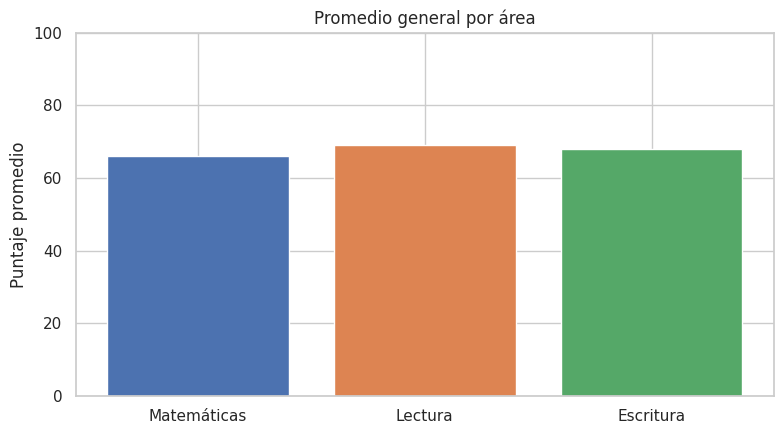

In [9]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(
    ["Matemáticas", "Lectura", "Escritura"],
    df[COLS_NOTAS].mean(),
    color=["#4c72b0", "#dd8452", "#55a868"],
)
ax.set_ylim(0, 100)
ax.set_ylabel("Puntaje promedio")
ax.set_title("Promedio general por área")
plt.tight_layout()
plt.show()

### 5.2 Curso de preparación vs. promedio

Comparación entre quienes completaron el curso de preparación y quienes no, con una prueba t de Welch (varianzas no asumidas iguales) sobre el promedio general.

In [10]:
curso = df.groupby("test_preparation_course")[COLS_NOTAS + ["average_score"]].mean()
display(curso)

completado = df.loc[df["test_preparation_course"] == "completed", "average_score"]
ninguno = df.loc[df["test_preparation_course"] == "none", "average_score"]
t, p = stats.ttest_ind(completado, ninguno, equal_var=False)

veredicto = "diferencia significativa" if p < 0.05 else "diferencia no significativa"
print(f"Prueba t: t={t:.3f}, p={p:.2e} ({veredicto})")

,math_score,reading_score,writing_score,average_score
test_preparation_course,,,,
completed,69.70,73.89,74.42,72.67
none,64.08,66.53,64.50,65.04


Prueba t: t=8.595, p=4.42e-17 (diferencia significativa)


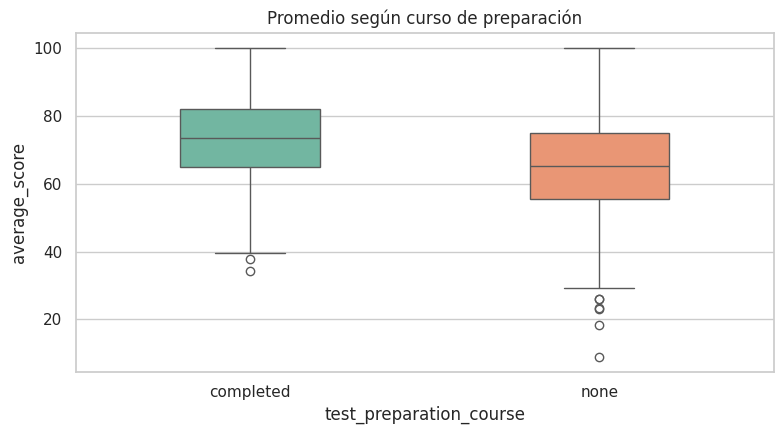

In [11]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(
    data=df,
    x="test_preparation_course",
    y="average_score",
    hue="test_preparation_course",
    order=["completed", "none"],
    hue_order=["completed", "none"],
    palette="Set2",
    width=0.4,
    legend=False,
    ax=ax,
)
ax.set_title("Promedio según curso de preparación")
plt.tight_layout()
plt.show()

### 5.3 Promedio según escolaridad de los padres

In [12]:
escolaridad = df.groupby("parental_level_of_education", observed=True)["average_score"].mean()
escolaridad.to_frame("promedio")

,promedio
parental_level_of_education,
some high school,65.11
high school,63.10
some college,68.48
associate's degree,69.57
bachelor's degree,71.92
master's degree,73.60


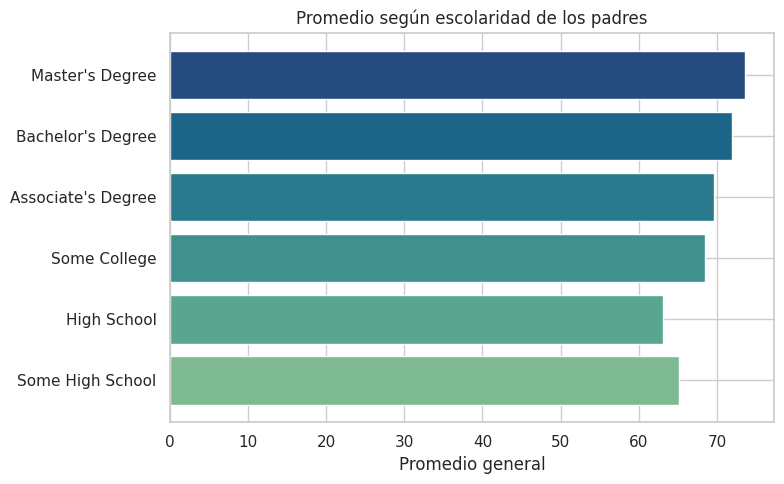

In [13]:
etiquetas = [e.title().replace("'S", "'s") for e in escolaridad.index]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(etiquetas, escolaridad.values, color=sns.color_palette("crest", len(escolaridad)))
ax.set_xlabel("Promedio general")
ax.set_title("Promedio según escolaridad de los padres")
plt.tight_layout()
plt.show()

### 5.4 Promedio por grupo (etnia, género, tipo de comida)

In [14]:
for col in ["race_ethnicity", "gender", "lunch"]:
    print(f"--- {col} ---")
    display(df.groupby(col)["average_score"].mean().sort_values(ascending=False).to_frame("promedio"))

--- race_ethnicity ---


,promedio
race_ethnicity,
group e,72.75
group d,69.18
group c,67.13
group b,65.47
group a,62.99


--- gender ---


,promedio
gender,
female,69.57
male,65.84


--- lunch ---


,promedio
lunch,
standard,70.84
free/reduced,62.20


### 5.5 Porcentaje de estudiantes por umbral de promedio

Cuántos estudiantes alcanzan como mínimo cada umbral, y su distribución por nivel de rendimiento.

In [15]:
total = len(df)
for umbral in [50, 60, 70, 80, 90]:
    n = (df["average_score"] >= umbral).sum()
    print(f"Promedio >= {umbral}: {n} ({n / total:.1%})")

Promedio >= 50: 897 (89.7%)
Promedio >= 60: 715 (71.5%)
Promedio >= 70: 459 (45.9%)
Promedio >= 80: 198 (19.8%)
Promedio >= 90: 52 (5.2%)


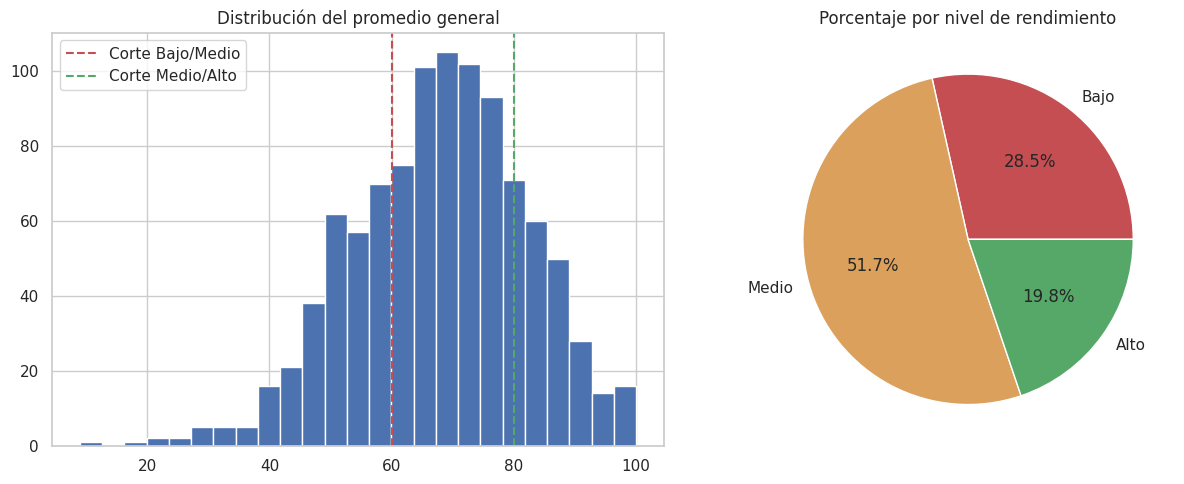

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histograma con los cortes de nivel
axes[0].hist(df["average_score"], bins=25, color="#4c72b0", edgecolor="white")
axes[0].axvline(60, color="#c44e52", linestyle="--", label="Corte Bajo/Medio")
axes[0].axvline(80, color="#55a868", linestyle="--", label="Corte Medio/Alto")
axes[0].set_title("Distribución del promedio general")
axes[0].legend()

# Porcentaje por nivel
conteo = df["performance_level"].value_counts().reindex(NIVELES)
axes[1].pie(
    conteo,
    labels=conteo.index,
    autopct="%1.1f%%",
    colors=["#c44e52", "#dba05b", "#55a868"],
)
axes[1].set_title("Porcentaje por nivel de rendimiento")

plt.tight_layout()
plt.show()

### 5.6 Correlación entre áreas

In [17]:
with pd.option_context("display.float_format", "{:.3f}".format):
    display(df[COLS_NOTAS].corr())

,math_score,reading_score,writing_score
math_score,1.000,0.818,0.803
reading_score,0.818,1.000,0.955
writing_score,0.803,0.955,1.000


## 6. Conclusiones

- **Áreas:** lectura es el área con mejor promedio (69.17), seguida de escritura (68.05) y matemáticas (66.09).
- **Curso de preparación:** quienes lo completaron promedian 72.67 frente a 65.04 de quienes no, unos 7.6 puntos más. La diferencia es estadísticamente significativa (t = 8.595, p ≈ 4.4e-17).
- **Escolaridad de los padres:** el promedio más alto corresponde a hijos de padres con maestría (73.60) y el más bajo a los de padres con bachillerato terminado (63.10). La tendencia general es ascendente, con la excepción de *some high school* (65.11), que supera a *high school*.
- **Grupos:** el grupo E tiene el promedio más alto (72.75) y el grupo A el más bajo (62.99). Las mujeres promedian más que los hombres (69.57 vs. 65.84) y quienes tienen comida estándar superan a quienes tienen comida gratuita o reducida (70.84 vs. 62.20).
- **Niveles de rendimiento:** 28.5 % de los estudiantes tiene nivel bajo, 51.7 % medio y 19.8 % alto. El 71.5 % alcanza un promedio de al menos 60 y solo el 5.2 % llega a 90 o más.
- **Correlaciones:** lectura y escritura están casi alineadas (0.955); matemáticas se relaciona algo menos con ambas (0.818 con lectura y 0.803 con escritura).

Estos resultados describen asociaciones entre variables; por sí solos no permiten afirmar que un factor (por ejemplo, el curso de preparación) cause la diferencia en el rendimiento.

## 7. Apéndice: salida original del análisis

Contenido íntegro de `resumen_analisis.txt`, generado por la ejecución original del análisis.

```text
=== Dataset cargado ===
Filas: 1000 | Columnas: 8

=== Nombre de las variables ===
gender, race/ethnicity, parental level of education, lunch, test preparation course, math score, reading score, writing score

=== Tipos de datos ===
gender                           str
race/ethnicity                   str
parental level of education      str
lunch                            str
test preparation course          str
math score                     int64
reading score                  int64
writing score                  int64

=== Valores faltantes ===
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0

=== Registros duplicados ===
0

=== Estadísticas descriptivas (numéricas) ===
       math score  reading score  writing score
count     1000.00        1000.00        1000.00
mean        66.09          69.17          68.05
std         15.16          14.60          15.20
min          0.00          17.00          10.00
25%         57.00          59.00          57.75
50%         66.00          70.00          69.00
75%         77.00          79.00          79.00
max        100.00         100.00         100.00

=== Limpieza aplicada ===
Columnas a snake_case, texto normalizado, duplicados eliminados, tipos corregidos, nivel educativo ordenado como categórico ordinal.

=== Clasificación de rendimiento ===
Bajo: <60 | Medio: 60-79.9 | Alto: >=80
performance_level
Bajo     285
Medio    517
Alto     198

=== 1) Promedio por área ===
reading_score    69.17
writing_score    68.05
math_score       66.09

=== 2) Curso de preparación vs. promedio ===
                         math_score  reading_score  writing_score  average_score
test_preparation_course                                                         
completed                     69.70          73.89          74.42          72.67
none                          64.08          66.53          64.50          65.04

Prueba t: t=8.595, p=4.42e-17 (diferencia significativa)

=== 3) Promedio según escolaridad de los padres ===
parental_level_of_education
some high school      65.11
high school           63.10
some college          68.48
associate's degree    69.57
bachelor's degree     71.92
master's degree       73.60

=== 4) Promedio por grupo (etnia, género, tipo de comida) ===

--- race_ethnicity ---
race_ethnicity
group e    72.75
group d    69.18
group c    67.13
group b    65.47
group a    62.99

--- gender ---
gender
female    69.57
male      65.84

--- lunch ---
lunch
standard        70.84
free/reduced    62.20


=== 5) Porcentaje de estudiantes por umbral de promedio ===
Promedio >= 50: 897 (89.7%)
Promedio >= 60: 715 (71.5%)
Promedio >= 70: 459 (45.9%)
Promedio >= 80: 198 (19.8%)
Promedio >= 90: 52 (5.2%)

=== 6) Correlación entre áreas ===
               math_score  reading_score  writing_score
math_score          1.000          0.818          0.803
reading_score       0.818          1.000          0.955
writing_score       0.803          0.955          1.000

=== Gráficas generadas ===
01_promedio_por_area.png, 02_curso_preparacion.png, 03_escolaridad_padres.png, 04_distribucion_niveles.png (en outputs/resultados/)

=== Proceso terminado ===
Resultados guardados en: /home/claude/proyecto/analisis-rendimiento-estudiantes/outputs/resultados
```